## Planteamiento


 **¿cuál es la probabilidad de que en un grupo de $n$ personas al menos dos compartan el mismo día de cumpleaños?**

Spoiler alert: con solo **23 personas** la probabilidad ya supera el 50%.

### Supuestos del modelo

Para simplificar el análisis, asumimos lo siguiente:

1. El año tiene exactamente **365 días** (ignoramos años bisiestos).
2. Los cumpleaños se distribuyen **uniformemente**: cada día del año es igualmente probable.
3. Los cumpleaños de distintas personas son **independientes** entre sí.

Estos supuestos no son perfectamente realistas (en la práctica hay meses con más nacimientos que otros), pero simplifican el cálculo y la conclusión cualitativa se mantiene.

## Solución 

En lugar de calcular directamente la probabilidad de que haya al menos una coincidencia (lo cual involucra muchos casos), usamos el **complemento**: calculamos la probabilidad de que **todos** tengan cumpleaños distintos y luego restamos de 1.

### Construcción paso a paso

Imaginemos que las $n$ personas entran a una sala una por una:

- **Persona 1**: puede tener cualquier cumpleaños. Probabilidad de no repetir: $\frac{365}{365} = 1$.
- **Persona 2**: para no repetir, su cumpleaños debe caer en uno de los 364 días restantes: $\frac{364}{365}$.
- **Persona 3**: debe evitar los 2 días ya tomados: $\frac{363}{365}$.
- **Persona $k$**: debe evitar los $k-1$ días ya ocupados: $\frac{365 - (k-1)}{365}$.

Como los cumpleaños son independientes, multiplicamos todas estas probabilidades:

$$
P(\text{todos distintos}) = \frac{365}{365} \cdot \frac{364}{365} \cdot \frac{363}{365} \cdots \frac{365 - n + 1}{365} = \prod_{k=0}^{n-1} \frac{365 - k}{365}
$$

Finalmente, la probabilidad de que **al menos dos** personas compartan cumpleaños es:

$$
P(\text{coincidencia}) = 1 - \prod_{k=0}^{n-1} \frac{365 - k}{365}
$$

Esta es una expresión exacta que podemos evaluar numéricamente para cualquier valor de $n$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Definimos la función `prob_analitica(n)` que implementa la fórmula exacta. El algoritmo es directo:

1. Inicializamos `p_todos_distintos = 1.0` (probabilidad acumulada).
2. En cada iteración $k = 0, 1, \ldots, n-1$, multiplicamos por $\frac{365 - k}{365}$, que es la probabilidad de que la persona $k+1$ no repita ningún cumpleaños previo.
3. Al final, restamos de 1 para obtener la probabilidad de coincidencia.

Luego evaluamos la función para todos los tamaños de grupo de 1 a 80 y buscamos el primer $n$ donde $P > 0.5$.

In [3]:
def prob_analitica(n, dias=365):
    """Probabilidad exacta de al menos una coincidencia en un grupo de n personas."""
    p_todos_distintos = 1.0
    for k in range(n):
        p_todos_distintos *= (dias - k) / dias
    return 1 - p_todos_distintos


for n in range(1, 101):
    p = prob_analitica(n)
    print(f"n = {n:3d} personas → P(coincidencia) = {p:.4f}")

n =   1 personas → P(coincidencia) = 0.0000
n =   2 personas → P(coincidencia) = 0.0027
n =   3 personas → P(coincidencia) = 0.0082
n =   4 personas → P(coincidencia) = 0.0164
n =   5 personas → P(coincidencia) = 0.0271
n =   6 personas → P(coincidencia) = 0.0405
n =   7 personas → P(coincidencia) = 0.0562
n =   8 personas → P(coincidencia) = 0.0743
n =   9 personas → P(coincidencia) = 0.0946
n =  10 personas → P(coincidencia) = 0.1169
n =  11 personas → P(coincidencia) = 0.1411
n =  12 personas → P(coincidencia) = 0.1670
n =  13 personas → P(coincidencia) = 0.1944
n =  14 personas → P(coincidencia) = 0.2231
n =  15 personas → P(coincidencia) = 0.2529
n =  16 personas → P(coincidencia) = 0.2836
n =  17 personas → P(coincidencia) = 0.3150
n =  18 personas → P(coincidencia) = 0.3469
n =  19 personas → P(coincidencia) = 0.3791
n =  20 personas → P(coincidencia) = 0.4114
n =  21 personas → P(coincidencia) = 0.4437
n =  22 personas → P(coincidencia) = 0.4757
n =  23 personas → P(coincidenci

## Simulación por Monte Carlo

Antes de armar la simulación completa, veamos paso a paso cómo funciona **un solo experimento**. Supongamos un grupo de 5 personas:

**Paso 1 — Generar cumpleaños aleatorios:** asignamos a cada persona un número entero entre 0 y 364. Cada número representa un día del año (0 = 1 de enero, 364 = 31 de diciembre).

**Paso 2 — Detectar repetidos:** convertimos la lista a un conjunto (`set`), que automáticamente elimina duplicados. Si el conjunto tiene **menos elementos** que la lista original, significa que al menos dos personas comparten cumpleaños.

In [12]:
# Paso 1: Generar cumpleaños aleatorios para 5 personas
rng = np.random.default_rng(42)
n = 
cumples = rng.integers(0, 365, size=n)
print(f"Grupo de {n} personas")
print(f"Cumpleaños generados (día del año): {cumples}")


Grupo de 40 personas
Cumpleaños generados (día del año): [ 32 282 238 160 158 313  31 254  73  34 192 356 268 277 261 286 187  46
 306 164 182 135  66 338 285 235 146 300 199 161 164  82  33 202 324  23
 313 302 101 230]


In [13]:
# Paso 2: Convertir a conjunto para eliminar duplicados
cumples_unicos = set(cumples)
print(f"Cumpleaños únicos (sin repetidos):  {cumples_unicos} y son {len(cumples_unicos)}")

Cumpleaños únicos (sin repetidos):  {np.int64(261), np.int64(135), np.int64(268), np.int64(146), np.int64(277), np.int64(23), np.int64(282), np.int64(285), np.int64(286), np.int64(158), np.int64(32), np.int64(160), np.int64(34), np.int64(31), np.int64(164), np.int64(161), np.int64(33), np.int64(300), np.int64(46), np.int64(302), np.int64(306), np.int64(182), np.int64(313), np.int64(187), np.int64(192), np.int64(66), np.int64(324), np.int64(199), np.int64(73), np.int64(202), np.int64(338), np.int64(82), np.int64(356), np.int64(101), np.int64(230), np.int64(235), np.int64(238), np.int64(254)} y son 38


In [14]:
# Paso 3: Comparar tamaños
print(f"\nTotal de personas:           {len(cumples)}")
print(f"Cumpleaños distintos:        {len(cumples_unicos)}")

if len(cumples_unicos) < n:
    print("→ ¡Hay al menos una coincidencia!")
else:
    print("→ No hay coincidencias en este grupo.")


Total de personas:           40
Cumpleaños distintos:        38
→ ¡Hay al menos una coincidencia!


### La simulación completa

Ahora encapsulamos esta lógica en una función `simular_cumpleanos` que repite el experimento `n_sim` veces y cuenta en qué fracción hubo coincidencia. Luego la ejecutamos para grupos de 1 a 100 personas.

In [17]:
def simular_cumpleanos(n, n_sim=1000, dias=365, seed=42):
    """Estima la probabilidad de coincidencia por simulación."""
    rng = np.random.default_rng(seed)
    coincidencias = 0
    for _ in range(n_sim):
        cumples = rng.integers(0, dias, size=n)
        if len(set(cumples)) < n:
            coincidencias += 1
    return coincidencias / n_sim


# Simular para varios tamaños de grupo (1 a 100 personas)
ns_sim = np.arange(1, 101)
probs_sim = [simular_cumpleanos(n) for n in ns_sim]
probs_sim

[0.0,
 0.004,
 0.006,
 0.02,
 0.02,
 0.046,
 0.058,
 0.073,
 0.103,
 0.114,
 0.137,
 0.167,
 0.209,
 0.216,
 0.262,
 0.283,
 0.301,
 0.348,
 0.361,
 0.397,
 0.429,
 0.455,
 0.493,
 0.534,
 0.553,
 0.6,
 0.611,
 0.637,
 0.656,
 0.703,
 0.714,
 0.756,
 0.761,
 0.793,
 0.776,
 0.81,
 0.855,
 0.867,
 0.874,
 0.877,
 0.894,
 0.898,
 0.915,
 0.934,
 0.947,
 0.944,
 0.958,
 0.963,
 0.964,
 0.963,
 0.972,
 0.976,
 0.977,
 0.981,
 0.984,
 0.982,
 0.988,
 0.982,
 0.988,
 0.989,
 0.993,
 0.993,
 0.995,
 0.999,
 0.997,
 0.996,
 0.997,
 0.998,
 0.996,
 0.998,
 0.999,
 1.0,
 0.999,
 0.998,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

## Comparación: analítica vs. simulación

El siguiente gráfico superpone ambos resultados: la curva azul es la solución analítica exacta y los puntos rojos son las estimaciones por simulación. Si la simulación está bien implementada, los puntos deberían caer muy cerca de la curva teórica.

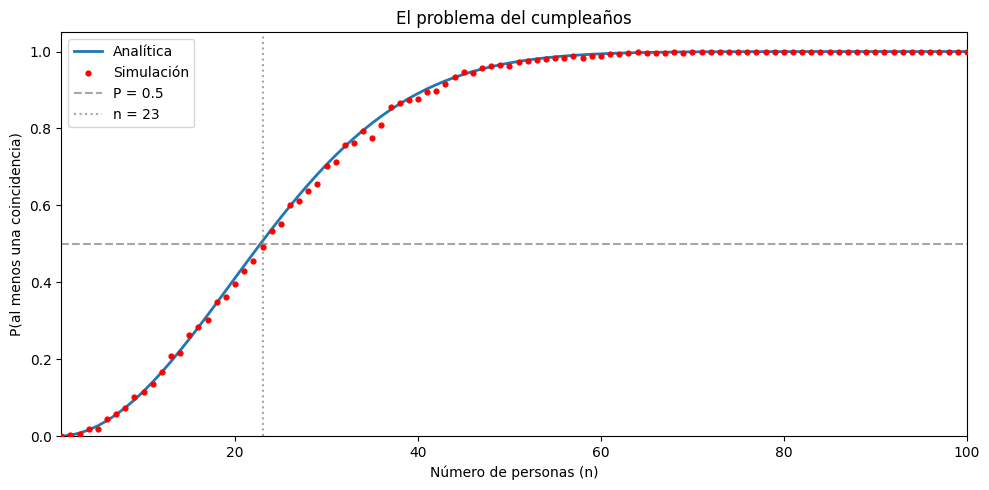

In [18]:
ns = np.arange(1, 101)
probs = [prob_analitica(n) for n in ns]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ns, probs, label="Analítica", linewidth=2)
ax.scatter(ns_sim, probs_sim, s=12, color="red", label="Simulación", zorder=5)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="P = 0.5")
ax.axvline(23, color="gray", linestyle=":", alpha=0.7, label="n = 23")

ax.set_xlabel("Número de personas (n)")
ax.set_ylabel("P(al menos una coincidencia)")
ax.set_title("El problema del cumpleaños")
ax.legend()
ax.set_xlim(1, 100)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
from math import comb

for n in [10, 23, 30, 50, 70]:
    pares = comb(n, 2)
    print(f"n = {n:2d} → {pares:4d} pares, P = {prob_analitica(n):.4f}")